In [ ]:
#CELL 1 — Install & imports
!pip install -q tensorflow numpy pillow tqdm scikit-learn matplotlib

import os, glob, math, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models, callbacks, optimizers
from tqdm import tqdm

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU available: []


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — Mount Drive & configure paths  (CORRECTED)     ║
# ╚══════════════════════════════════════════════════════════╝
from google.colab import drive
drive.mount('/content/drive')

# ── Edit this to match your Drive location ────────────────
BASE_DIR = "/content/drive/MyDrive/Optimus_Stratus_dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "training")
VAL_DIR   = os.path.join(BASE_DIR, "validation")
TEST_DIR  = os.path.join(BASE_DIR, "testing")

IMG_SIZE = 96
BATCH    = 32
AUTOTUNE = tf.data.AUTOTUNE

CKPT_PATH  = "/content/model_best.weights.h5"
TFLITE_OUT = "/content/drive/MyDrive/cloud_classifier.tflite"

# Verify TFRecords are visible across all splits and classes
for split, path in [("training", TRAIN_DIR), ("validation", VAL_DIR), ("testing", TEST_DIR)]:
    for cls in ["Cloudy", "NonCloudy"]:
        cls_path = os.path.join(path, cls)
        n = len(glob.glob(os.path.join(cls_path, "*.tfrecord")))
        print(f"  {split:12s} / {cls:10s} : {n} TFRecords")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  training     / Cloudy     : 640 TFRecords
  training     / NonCloudy  : 820 TFRecords
  validation   / Cloudy     : 88 TFRecords
  validation   / NonCloudy  : 136 TFRecords
  testing      / Cloudy     : 87 TFRecords
  testing      / NonCloudy  : 135 TFRecords


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 3 — Parser that skips corrupt records              ║
# ╚══════════════════════════════════════════════════════════╝
FEATURE_DESC = {
    "image":    tf.io.FixedLenFeature([], tf.string),
    "label":    tf.io.FixedLenFeature([], tf.string),
    "height":   tf.io.FixedLenFeature([], tf.int64),
    "width":    tf.io.FixedLenFeature([], tf.int64),
    "channels": tf.io.FixedLenFeature([], tf.int64),
}

IMG_SIZE = 96
BATCH    = 32
AUTOTUNE = tf.data.AUTOTUNE

def safe_parse(raw_bytes):
    """
    Returns (img [96,96,3] float32, label scalar float32).
    Returns sentinel (zeros, -1) for any corrupt record so we can filter them.
    """
    try:
        example = tf.train.Example()
        example.ParseFromString(raw_bytes.numpy())
        feats = example.features.feature

        h = int(feats["height"].int64_list.value[0])
        w = int(feats["width"].int64_list.value[0])
        c = int(feats["channels"].int64_list.value[0])

        img_bytes  = feats["image"].bytes_list.value[0]
        mask_bytes = feats["label"].bytes_list.value[0]

        # Validate byte counts before reshape
        expected_img  = h * w * c * 2   # float16 = 2 bytes
        expected_mask = h * w           # uint8   = 1 byte
        if len(img_bytes) != expected_img or len(mask_bytes) != expected_mask:
            return (
                np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32),
                np.array(-1.0, dtype=np.float32)   # sentinel
            )

        img  = np.frombuffer(img_bytes,  dtype=np.float16).reshape(h, w, c).astype(np.float32)
        mask = np.frombuffer(mask_bytes, dtype=np.uint8 ).reshape(h, w)  .astype(np.float32)

        # Normalise
        img_max = img.max()
        if img_max > 0:
            img = img / img_max
        img = np.clip(img, 0.0, 1.0)

        # Resize both to IMG_SIZE using PIL (no TF graph issues)
        from PIL import Image as PILImage
        img_pil  = np.stack([
            np.array(PILImage.fromarray(img[:,:,ch]).resize(
                (IMG_SIZE, IMG_SIZE), PILImage.Resampling.BILINEAR))
            for ch in range(c)
        ], axis=-1)
        mask_pil = np.array(
            PILImage.fromarray(mask).resize(
                (IMG_SIZE, IMG_SIZE), PILImage.Resampling.NEAREST))

        img_pil  = np.clip(img_pil, 0.0, 1.0).astype(np.float32)
        label    = np.float32(mask_pil.mean() > 0.2)

        return img_pil, label

    except Exception:
        return (
            np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32),
            np.array(-1.0, dtype=np.float32)   # sentinel
        )


def parse_tfrecord(raw_bytes):
    img, label = tf.py_function(
        func=safe_parse,
        inp=[raw_bytes],
        Tout=[tf.float32, tf.float32]
    )
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    label.set_shape([])
    return img, label


def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


def make_dataset(directory, augment_data=False, shuffle=False):
    files = (
        glob.glob(os.path.join(directory, "Cloudy",    "*.tfrecord")) +
        glob.glob(os.path.join(directory, "NonCloudy", "*.tfrecord"))
    )
    assert files, f"No TFRecords found under {directory}"
    print(f"  Loaded {len(files)} files from {os.path.basename(directory)}/")

    ds = tf.data.TFRecordDataset(files, num_parallel_reads=AUTOTUNE)
    ds = ds.map(parse_tfrecord, num_parallel_calls=AUTOTUNE)

    # Drop corrupt records (label == -1)
    ds = ds.filter(lambda img, label: label >= 0)

    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(TRAIN_DIR, augment_data=True,  shuffle=True)
val_ds   = make_dataset(VAL_DIR,   augment_data=False, shuffle=False)
test_ds  = make_dataset(TEST_DIR,  augment_data=False, shuffle=False)

# Sanity check
for imgs, labels in train_ds.take(1):
    print("Batch shape  :", imgs.shape)        # expect (32, 96, 96, 3)
    print("Pixel range  :", imgs.numpy().min().round(3), "-", imgs.numpy().max().round(3))
    print("Cloudy ratio :", labels.numpy().mean().round(3))

  Loaded 1460 files from training/
  Loaded 224 files from validation/
  Loaded 222 files from testing/
Batch shape  : (32, 96, 96, 3)
Pixel range  : 0.0 - 1.0
Cloudy ratio : 0.375


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — Build model                                    ║
# ╚══════════════════════════════════════════════════════════╝
def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), freeze_base=True):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )
    base.trainable = not freeze_base

    inputs = tf.keras.Input(shape=input_shape)
    # Images are already [0,1] from safe_parse — scale to [0,255] for
    # MobileNetV2's preprocess_input which maps to [-1,1] internally
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    return model, base

model, base_model = build_model(freeze_base=True)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — Phase 1: Train head only                       ║
# ╚══════════════════════════════════════════════════════════╝
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

cb_ckpt = callbacks.ModelCheckpoint(
    CKPT_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)
cb_early = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5,
    restore_best_weights=True, verbose=1
)
cb_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

print("=== Phase 1: head-only training ===")
history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[cb_ckpt, cb_early, cb_lr]
)

=== Phase 1: head-only training ===
Epoch 1/10
     46/Unknown 20s 168ms/step - accuracy: 0.9243 - auc: 0.9676 - loss: 0.1508 - precision: 0.9165 - recall: 0.8998

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from None to 0.90625, saving model to /content/model_best.weights.h5

Epoch 1: finished saving model to /content/model_best.weights.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 46s 747ms/step - accuracy: 0.9767 - auc: 0.9983 - loss: 0.0543 - precision: 0.9749 - recall: 0.9718 - val_accuracy: 0.9062 - val_auc: 0.9637 - val_loss: 0.6618 - val_precision: 1.0000 - val_recall: 0.8827 - learning_rate: 0.0010
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9957 - auc: 0.9999 - loss: 0.0103 - precision: 0.9965 - recall: 0.9936
Epoch 2: val_accuracy did not improve from 0.90625
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 216ms/step - accuracy: 0.9952 - auc: 0.9999 - loss: 0.0133 - precision: 0.9953 - recall: 0.9937 - val_accuracy: 0.8750 - val_auc: 0.9525 - val_loss: 0.9017 - val_precision: 1.0000 - val_recall: 0.8436 - learning_rate: 0.0010
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9997 - auc: 1.0000 - loss: 0.0021 - precision: 0.9997 - recall: 0.9

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — Phase 2: Fine-tune top 30 layers               ║
# ╚══════════════════════════════════════════════════════════╝
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers : {sum(1 for l in model.layers if l.trainable)}")
print(f"Frozen layers    : {sum(1 for l in model.layers if not l.trainable)}")

# Correctly calculate total_steps based on known dataset size
# Number of training samples is 1460 (from Cell 3 output)
total_train_samples = 1460 # Manually obtained from previous cell output for make_dataset(TRAIN_DIR)
total_steps = math.ceil(total_train_samples / BATCH) * 15
lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=total_steps,
    alpha=1e-7
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

cb_ckpt2 = callbacks.ModelCheckpoint(
    CKPT_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)
cb_early2 = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5,
    restore_best_weights=True, verbose=1
)

print("=== Phase 2: fine-tuning top 30 layers ===")
history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[cb_ckpt2, cb_early2]
)


Trainable layers : 6
Frozen layers    : 0
=== Phase 2: fine-tuning top 30 layers ===
Epoch 1/15
     46/Unknown 35s 316ms/step - accuracy: 0.8440 - auc: 0.9382 - loss: 0.5896 - precision: 0.9991 - recall: 0.6561
Epoch 1: val_accuracy improved from None to 0.90625, saving model to /content/model_best.weights.h5

Epoch 1: finished saving model to /content/model_best.weights.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 39s 413ms/step - accuracy: 0.9040 - auc: 0.9695 - loss: 0.3471 - precision: 0.9980 - recall: 0.7825 - val_accuracy: 0.9062 - val_auc: 0.9581 - val_loss: 0.8347 - val_precision: 1.0000 - val_recall: 0.8827
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9746 - auc: 0.9961 - loss: 0.0708 - precision: 0.9959 - recall: 0.9466
Epoch 2: val_accuracy did not improve from 0.90625
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 368ms/step - accuracy: 0.9767 - auc: 0.9969 - loss: 0.0692 - precision: 0.9951 - recall: 0.9515 - val_accuracy: 0.9062 - val_auc: 0.9581 - val_loss: 0.8548 - val_precision

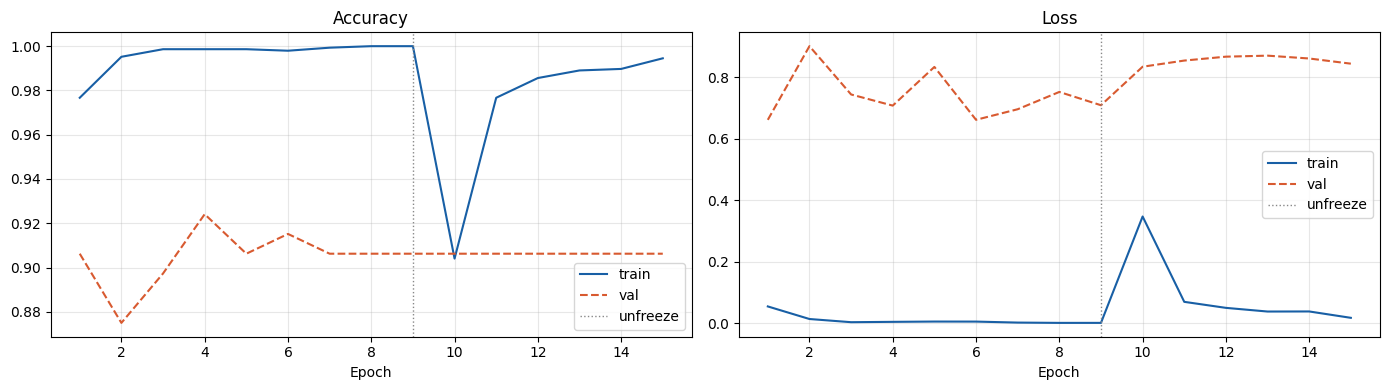

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — Plot training curves                           ║
# ╚══════════════════════════════════════════════════════════╝
def plot_history(h1, h2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    metrics = ["accuracy", "loss"]
    colors  = {"train": "#185FA5", "val": "#D85A30"}

    for ax, metric in zip(axes, metrics):
        v1     = h1.history.get(metric, [])
        v1_val = h1.history.get(f"val_{metric}", [])
        v2     = h2.history.get(metric, [])
        v2_val = h2.history.get(f"val_{metric}", [])

        combined     = v1 + v2
        combined_val = v1_val + v2_val
        split        = len(v1)
        xs           = list(range(1, len(combined) + 1))

        ax.plot(xs, combined,     color=colors["train"], label="train")
        ax.plot(xs, combined_val, color=colors["val"],   label="val", linestyle="--")
        ax.axvline(split, color="#888", linestyle=":", linewidth=1, label="unfreeze")
        ax.set_title(metric.capitalize())
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/content/training_curves.png", dpi=150)
    plt.show()

plot_history(history_1, history_2)


===== Test Set Evaluation =====
              precision    recall  f1-score   support

   NonCloudy       0.99      1.00      1.00       135
      Cloudy       1.00      0.99      0.99        87

    accuracy                           1.00       222
   macro avg       1.00      0.99      1.00       222
weighted avg       1.00      1.00      1.00       222



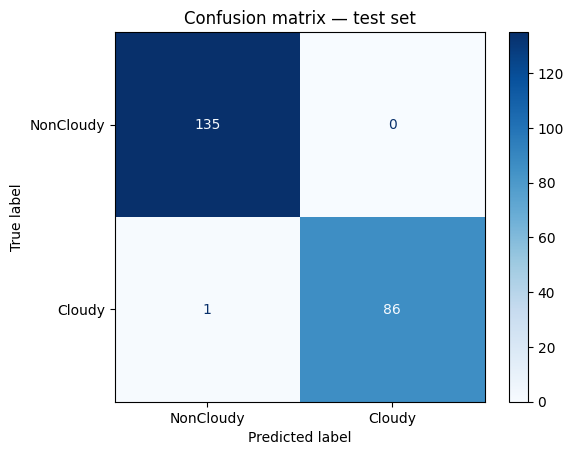

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — Evaluate best checkpoint on test set           ║
# ╚══════════════════════════════════════════════════════════╝

# Rebuild the exact same architecture from Cell 4
best_model, _ = build_model(freeze_base=False)

# Load only the weights — avoids TrueDivide deserialization entirely
best_model.load_weights(CKPT_PATH)

best_model.compile(
    optimizer=optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

y_true, y_pred_prob = [], []
for imgs, labels in test_ds:
    preds = best_model.predict(imgs, verbose=0).flatten()
    y_pred_prob.extend(preds.tolist())
    y_true.extend(labels.numpy().tolist())

y_true      = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred      = (y_pred_prob > 0.5).astype(int)

print("\n===== Test Set Evaluation =====")
print(classification_report(y_true, y_pred, target_names=["NonCloudy", "Cloudy"]))

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NonCloudy", "Cloudy"])
disp.plot(cmap="Blues")
plt.title("Confusion matrix — test set")
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — Post-training full-integer quantization        ║
# ╚══════════════════════════════════════════════════════════╝
rep_samples = []
for imgs, _ in val_ds.unbatch().take(100):
    rep_samples.append(imgs.numpy())

rep_array = np.array(rep_samples, dtype=np.float32)   # (100, 96, 96, 3)

def representative_dataset():
    for sample in rep_array:
        yield [sample[np.newaxis, ...]]                # (1, 96, 96, 3)

# Use concrete function instead of from_keras_model to avoid TrueDivide issue
@tf.function(input_signature=[tf.TensorSpec(shape=[1, IMG_SIZE, IMG_SIZE, 3], dtype=tf.float32)])
def serving_fn(x):
    return best_model(x, training=False)

converter = tf.lite.TFLiteConverter.from_concrete_functions(
    [serving_fn.get_concrete_function()]
)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

with open(TFLITE_OUT, "wb") as f:
    f.write(tflite_model)

size_kb = os.path.getsize(TFLITE_OUT) / 1024
print(f"\nTFLite model saved → {TFLITE_OUT}")
print(f"File size : {size_kb:.1f} KB  ({size_kb/1024:.2f} MB)")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



TFLite model saved → /content/drive/MyDrive/cloud_classifier.tflite
File size : 2809.4 KB  (2.74 MB)


  MobileNetV2 — Test Set Evaluation
              precision    recall  f1-score   support

   NonCloudy       0.99      1.00      1.00       135
      Cloudy       1.00      0.99      0.99        87

    accuracy                           1.00       222
   macro avg       1.00      0.99      1.00       222
weighted avg       1.00      1.00      1.00       222

  MobileNetV2 TFLite (int8) — Test Set Evaluation
Input  shape/dtype : [ 1 96 96  3]  <class 'numpy.float32'>
Output shape/dtype : [1 1]  <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


              precision    recall  f1-score   support

   NonCloudy       0.96      1.00      0.98       135
      Cloudy       1.00      0.94      0.97        87

    accuracy                           0.98       222
   macro avg       0.98      0.97      0.98       222
weighted avg       0.98      0.98      0.98       222



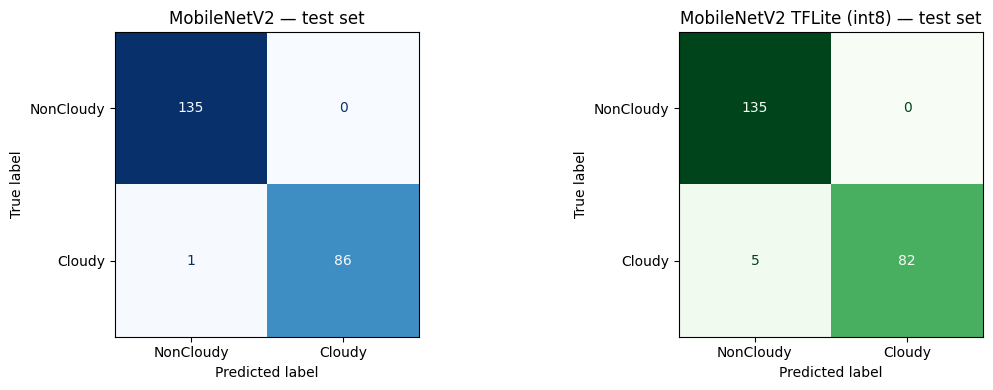

  MobileNetV2 vs MobileNetV2 TFLite (int8)
  MobileNetV2        accuracy : 0.9955  (99.55%)
  MobileNetV2 TFLite accuracy : 0.9775  (97.75%)
  Accuracy drop (quantization): 1.80%  (REVIEW — drop > 1%)
  MobileNetV2        F1 (weighted) : 0.9955
  MobileNetV2 TFLite F1 (weighted) : 0.9773


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 10 — Test MobileNetV2 + TFLite on test set         ║
# ╚══════════════════════════════════════════════════════════╝

# ── Part A: MobileNetV2 model on test set ────────────────────
print("=" * 50)
print("  MobileNetV2 — Test Set Evaluation")
print("=" * 50)

keras_true, keras_pred_prob = [], []
for imgs, labels in test_ds:
    preds = best_model.predict(imgs, verbose=0).flatten()
    keras_pred_prob.extend(preds.tolist())
    keras_true.extend(labels.numpy().tolist())

keras_true      = np.array(keras_true)
keras_pred_prob = np.array(keras_pred_prob)
keras_pred      = (keras_pred_prob > 0.5).astype(int)

print(classification_report(keras_true, keras_pred, target_names=["NonCloudy", "Cloudy"]))

cm_keras = confusion_matrix(keras_true, keras_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(cm_keras, display_labels=["NonCloudy", "Cloudy"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("MobileNetV2 — test set")

# ── Part B: MobileNetV2 TFLite on test set ───────────────────
print("=" * 50)
print("  MobileNetV2 TFLite (int8) — Test Set Evaluation")
print("=" * 50)

interpreter = tf.lite.Interpreter(model_path=TFLITE_OUT)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input  shape/dtype : {input_details[0]['shape']}  {input_details[0]['dtype']}")
print(f"Output shape/dtype : {output_details[0]['shape']}  {output_details[0]['dtype']}")

tfl_true, tfl_pred_prob = [], []
for imgs, labels in test_ds:
    for i in range(imgs.shape[0]):
        inp = imgs[i:i+1].numpy().astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], inp)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details[0]['index'])[0][0]
        tfl_pred_prob.append(float(out))
        tfl_true.append(int(labels[i].numpy()))

tfl_true      = np.array(tfl_true)
tfl_pred_prob = np.array(tfl_pred_prob)
tfl_pred      = (tfl_pred_prob > 0.5).astype(int)

print(classification_report(tfl_true, tfl_pred, target_names=["NonCloudy", "Cloudy"]))

cm_tfl = confusion_matrix(tfl_true, tfl_pred)
ConfusionMatrixDisplay(cm_tfl, display_labels=["NonCloudy", "Cloudy"]).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("MobileNetV2 TFLite (int8) — test set")

plt.tight_layout()
plt.savefig("/content/confusion_matrices.png", dpi=150)
plt.show()

# ── Part C: Side-by-side comparison ──────────────────────────
print("=" * 50)
print("  MobileNetV2 vs MobileNetV2 TFLite (int8)")
print("=" * 50)

keras_acc = (keras_pred == keras_true).mean()
tfl_acc   = (tfl_pred   == tfl_true).mean()
drop      = (keras_acc  - tfl_acc) * 100

print(f"  MobileNetV2        accuracy : {keras_acc:.4f}  ({keras_acc*100:.2f}%)")
print(f"  MobileNetV2 TFLite accuracy : {tfl_acc:.4f}  ({tfl_acc*100:.2f}%)")
print(f"  Accuracy drop (quantization): {drop:.2f}%  ({'OK' if drop < 1.0 else 'REVIEW — drop > 1%'})")

from sklearn.metrics import f1_score
keras_f1 = f1_score(keras_true, keras_pred, average="weighted")
tfl_f1   = f1_score(tfl_true,   tfl_pred,   average="weighted")
print(f"  MobileNetV2        F1 (weighted) : {keras_f1:.4f}")
print(f"  MobileNetV2 TFLite F1 (weighted) : {tfl_f1:.4f}")

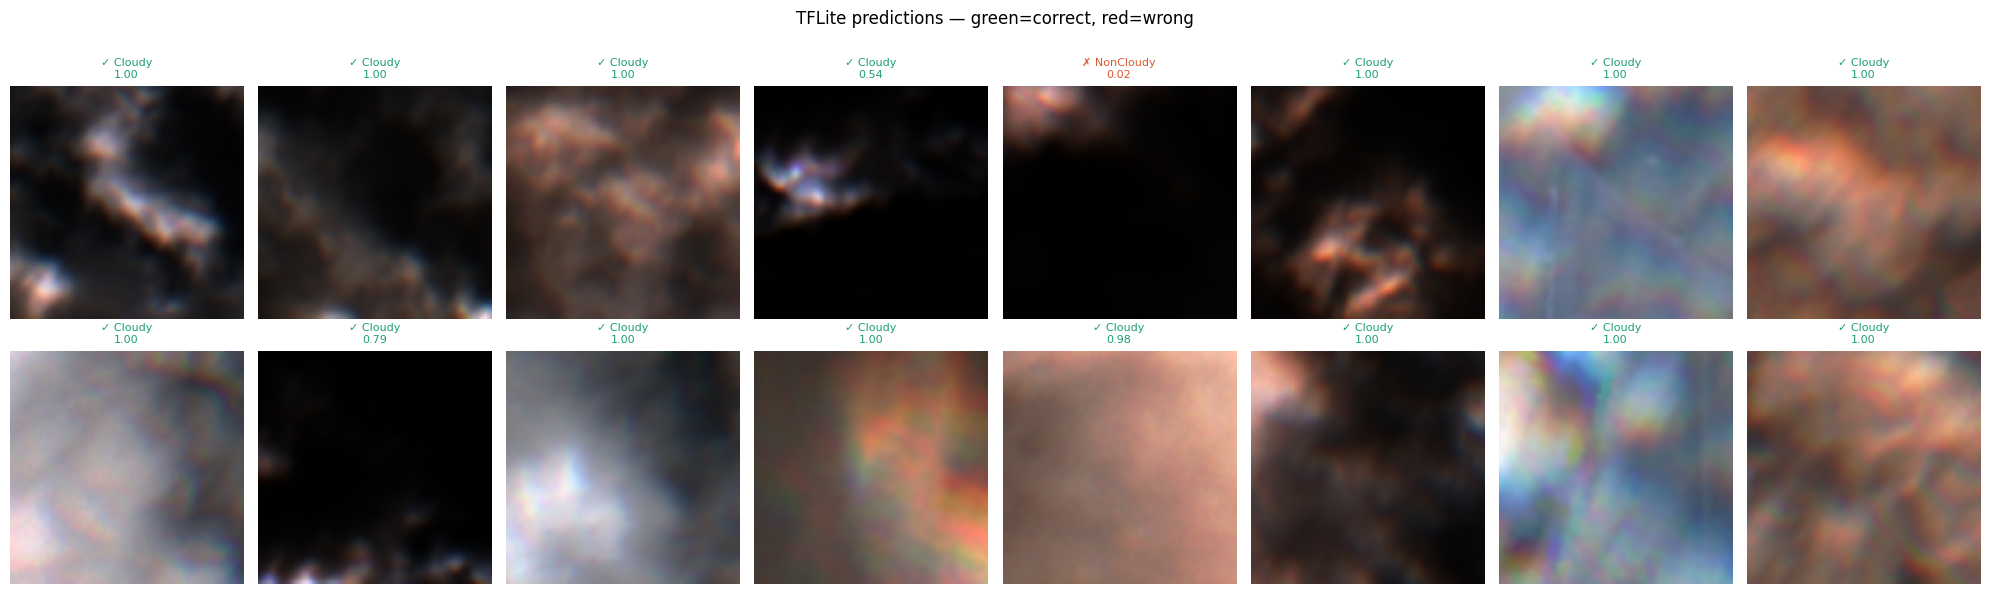

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 11 — Visualise sample predictions                  ║
# ╚══════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
labels_str   = ["NonCloudy", "Cloudy"]
class_colors = {"correct": "#1D9E75", "wrong": "#D85A30"}

sample_imgs, sample_labels = next(iter(test_ds.unbatch().batch(16)))
sample_imgs   = sample_imgs.numpy()
sample_labels = sample_labels.numpy().astype(int)

for idx, ax in enumerate(axes.flat):
    if idx >= len(sample_imgs):
        ax.axis("off")
        continue

    inp = sample_imgs[idx:idx+1].astype(np.float32)   # already [0,1]
    interpreter.set_tensor(input_details[0]['index'], inp)
    interpreter.invoke()
    prob = interpreter.get_tensor(output_details[0]['index'])[0][0]
    pred = int(prob > 0.5)

    ax.imshow(sample_imgs[idx])                        # [0,1] displays correctly
    ax.axis("off")

    color  = class_colors["correct"] if pred == sample_labels[idx] else class_colors["wrong"]
    status = "✓" if pred == sample_labels[idx] else "✗"
    ax.set_title(f"{status} {labels_str[pred]}\n{prob:.2f}", fontsize=8, color=color)

plt.suptitle("TFLite predictions — green=correct, red=wrong", y=1.01)
plt.tight_layout()
plt.savefig("/content/sample_predictions.png", dpi=150)
plt.show()

  1. CLASS DISTRIBUTION ACROSS SPLITS
  train  → total=1459  Cloudy= 639 (43.8%)  NonCloudy= 820 (56.2%)
  val    → total= 224  Cloudy= 179 (79.9%)  NonCloudy=  45 (20.1%)
  test   → total= 222  Cloudy=  87 (39.2%)  NonCloudy= 135 (60.8%)

  2. TRAIN vs VAL ACCURACY GAP
  Final train accuracy : 0.9945
  Final val   accuracy : 0.9062
  Best  val   accuracy : 0.9062
  Train-val gap        : 0.0883  ⚠ Mild overfitting — monitor closely

  3. PER-CLASS METRICS ON TEST SET
              precision    recall  f1-score   support

   NonCloudy     0.9926    1.0000    0.9963       135
      Cloudy     1.0000    0.9885    0.9942        87

    accuracy                         0.9955       222
   macro avg     0.9963    0.9943    0.9953       222
weighted avg     0.9955    0.9955    0.9955       222

  ► If minority class F1 << majority class F1,
    the model is biased toward the majority class.


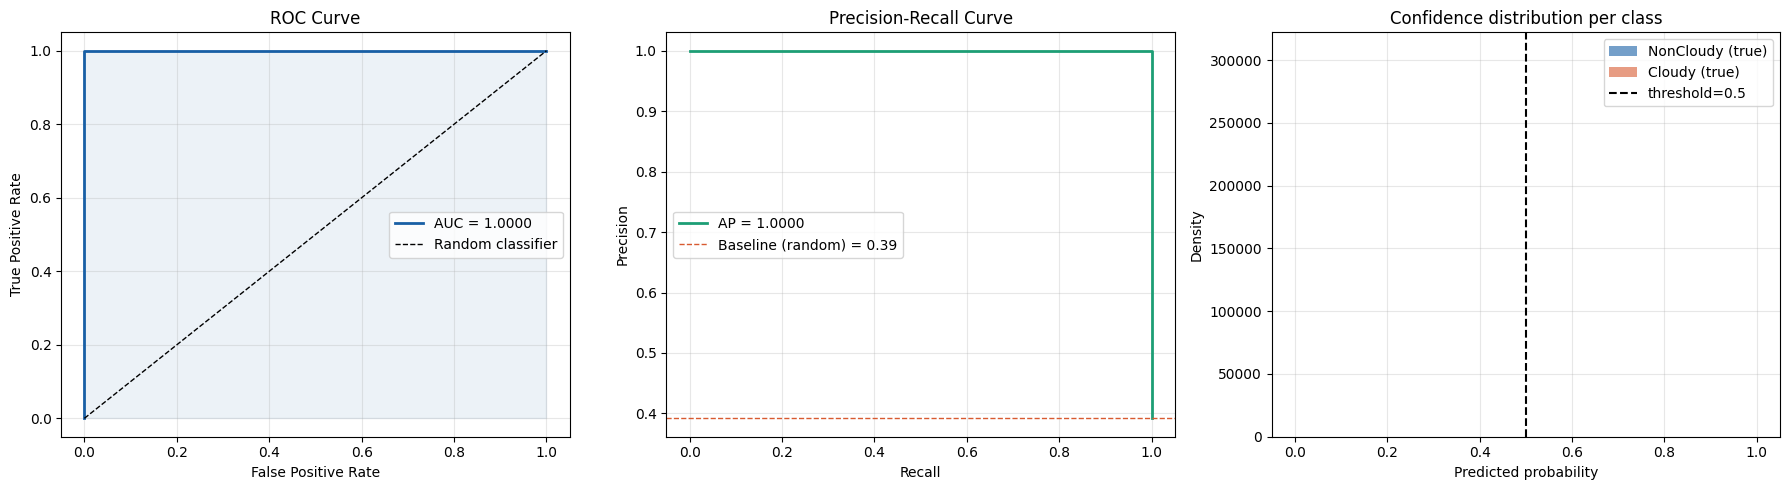

  4. CALIBRATION CHECK


AttributeError: module 'matplotlib.pyplot' has no attribute 'subplo'

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 12 — Overfitting & imbalance diagnostics           ║
# ╚══════════════════════════════════════════════════════════╝
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve

# ── 1. Dataset class distribution ────────────────────────────
print("=" * 55)
print("  1. CLASS DISTRIBUTION ACROSS SPLITS")
print("=" * 55)

for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    all_labels = np.concatenate([labels.numpy() for _, labels in ds])
    n_total   = len(all_labels)
    n_cloudy  = int(all_labels.sum())
    n_clear   = n_total - n_cloudy
    ratio     = n_cloudy / n_total
    print(f"  {name:6s} → total={n_total:4d}  "
          f"Cloudy={n_cloudy:4d} ({ratio*100:.1f}%)  "
          f"NonCloudy={n_clear:4d} ({(1-ratio)*100:.1f}%)")

# ── 2. Train vs Val accuracy gap (overfitting signal) ────────
print("\n" + "=" * 55)
print("  2. TRAIN vs VAL ACCURACY GAP")
print("=" * 55)

final_train_acc = history_2.history["accuracy"][-1]
final_val_acc   = history_2.history["val_accuracy"][-1]
best_val_acc    = max(history_2.history["val_accuracy"])
gap             = final_train_acc - final_val_acc

print(f"  Final train accuracy : {final_train_acc:.4f}")
print(f"  Final val   accuracy : {final_val_acc:.4f}")
print(f"  Best  val   accuracy : {best_val_acc:.4f}")
print(f"  Train-val gap        : {gap:.4f}", end="  ")
if gap < 0.05:
    print("✓ No significant overfitting")
elif gap < 0.10:
    print("⚠ Mild overfitting — monitor closely")
else:
    print("✗ Overfitting detected — consider more dropout/augmentation")

# ── 3. Per-class metrics (catches imbalance masking) ─────────
print("\n" + "=" * 55)
print("  3. PER-CLASS METRICS ON TEST SET")
print("=" * 55)
print(classification_report(
    keras_true, keras_pred,
    target_names=["NonCloudy", "Cloudy"],
    digits=4
))
print("  ► If minority class F1 << majority class F1,")
print("    the model is biased toward the majority class.")

# ── 4. ROC curve + AUC ───────────────────────────────────────
fpr, tpr, roc_thresh = roc_curve(keras_true, keras_pred_prob)
roc_auc = auc(fpr, tpr)

# ── 5. Precision-Recall curve (best for imbalanced data) ─────
precision, recall, pr_thresh = precision_recall_curve(keras_true, keras_pred_prob)
avg_precision = average_precision_score(keras_true, keras_pred_prob)
# Baseline = fraction of positive class
baseline = keras_true.mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot ROC
axes[0].plot(fpr, tpr, color="#185FA5", lw=2, label=f"AUC = {roc_auc:.4f}")
axes[0].plot([0,1],[0,1], "k--", lw=1, label="Random classifier")
axes[0].fill_between(fpr, tpr, alpha=0.08, color="#185FA5")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot PR curve
axes[1].plot(recall, precision, color="#1D9E75", lw=2, label=f"AP = {avg_precision:.4f}")
axes[1].axhline(baseline, color="#D85A30", lw=1, linestyle="--",
                label=f"Baseline (random) = {baseline:.2f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot confidence distribution per class
cloudy_probs    = keras_pred_prob[keras_true == 1]
noncloudy_probs = keras_pred_prob[keras_true == 0]
axes[2].hist(noncloudy_probs, bins=30, alpha=0.6, color="#185FA5",
             label="NonCloudy (true)", density=True)
axes[2].hist(cloudy_probs,    bins=30, alpha=0.6, color="#D85A30",
             label="Cloudy (true)",    density=True)
axes[2].axvline(0.5, color="black", lw=1.5, linestyle="--", label="threshold=0.5")
axes[2].set_xlabel("Predicted probability")
axes[2].set_ylabel("Density")
axes[2].set_title("Confidence distribution per class")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/diagnostics_roc_pr_conf.png", dpi=150)
plt.show()

# ── 6. Calibration curve (is the model overconfident?) ───────
print("=" * 55)
print("  4. CALIBRATION CHECK")
print("=" * 55)

prob_true, prob_pred = calibration_curve(keras_true, keras_pred_prob, n_bins=10)

fig, ax = plt.subplo